# Web Scraping

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
import pandas as pd
from time import sleep 
import numpy as np

In [21]:
service = Service()
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(service=service, options=options) #pobieramy całą stronę, a nie tylko html 
driver.get('https://gratka.pl/nieruchomosci/mieszkania/warszawa')
site = 'https://gratka.pl/nieruchomosci/mieszkania/warszawa' 
j =0
sleep(3)

gratka=[]

while j < 200:
    sleep(2)
    strona = driver.find_element(By.CSS_SELECTOR,'[data-v-f813640d]')
    items= strona.find_elements(By.CLASS_NAME,'card.card--bottom-margin')
    
    
    for i in items:
        try:
            opis =i.find_element(By.CLASS_NAME,'property-card__link').get_attribute('textContent').strip()
        except:
            opis = "NA"
            
        try:    
            link = i.find_element(By.CLASS_NAME,'property-card__link').get_attribute('href')
        except:
            link = "NA"
            
        try:    
            lokalizacja =i.find_element(By.CLASS_NAME,'property-card__location').get_attribute('textContent').strip()
        except:
            lokalizacja = "NA"
            
        try:    
            cena =i.find_element(By.CLASS_NAME,'property-card__price--main').get_attribute('textContent').strip()
        except:
            cena = "NA"
            
        try:    
            cena_metr =i.find_element(By.CLASS_NAME,'property-card__price--perM2').get_attribute('textContent').strip()
        except:
            cena_metr = "NA"
            
        try:    
            metraz = i.find_element(By.CSS_SELECTOR,'[data-cy="cardPropertyInfoArea"]').get_attribute('textContent').strip()
        except:
            metraz = "NA"
            
        try:
            pokoje = i.find_element(By.CSS_SELECTOR,'[data-cy="cardPropertyInfoRooms"]').get_attribute('textContent').strip()
        except:
            pokoje = "NA"
            
        try:
            pietro = i.find_element(By.CSS_SELECTOR,'[data-cy="cardPropertyInfoFloor"]').get_attribute('textContent').strip()
        except:
            pietro = "NA"

        gratka.append({
        "opis": opis,
        "link": link,
        "lokalizacja": lokalizacja,
        "cena": cena,
        "cena_metr": cena_metr,
        "metraż": metraz,
        "pokoje": pokoje,
        "piętro": pietro
        })

    driver.get(site+'?page='+str(j+2)+'/')
    j+=1
    sleep(2)
    
dane = pd.DataFrame(gratka)

In [6]:
podzielone = dane['lokalizacja'].str.split(r'\s*,\s*')

dlugosc = podzielone.str.len()
dane['województwo'] = np.where(dlugosc >=1, podzielone.str[-1], "NA") 
dane['miasto'] = np.where(dlugosc >=2, podzielone.str[-2], "NA") 
dane['dzielnica'] = np.where(dlugosc >=3, podzielone.str[-3], "NA") 
dane['osiedle'] = np.where(dlugosc ==5, podzielone.str[1], "NA") 
dane['ulica'] = np.where(dlugosc >=4, podzielone.str[0], "NA") 


NameError: name 'dane' is not defined

In [2]:
dane.to_csv('dane.csv', index=False)

NameError: name 'dane' is not defined

# Przetwarzanie i czyszczenie danych

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import geopandas

In [2]:
df = pd.read_csv('dane.csv')

dzielnice = [
    'Bemowo', 'Białołęka', 'Bielany', 'Mokotów', 'Ochota', 'Praga-Południe',
    'Praga-Północ', 'Rembertów', 'Śródmieście', 'Targówek', 'Ursus', 'Ursynów',
    'Wawer', 'Wesoła','Wilanów', 'Włochy', 'Wola', 'Żoliborz'
]

def dzielnice_czyste(lokalizacja):
    if pd.isna(lokalizacja):
        return 'NA'
    for i in dzielnice:
        if i in str(lokalizacja):
            return i
    return 'NA'

df['dzielnica'] = df['lokalizacja'].apply(dzielnice_czyste)

In [3]:
df_czyste = df[(df['dzielnica'] != 'NA') & (df['cena_metr'] != 'NA')].copy()

df_czyste['cena_metr_czysta'] = (
    df_czyste['cena_metr']
    .astype(str)
    .str.replace(' ', '')
    .str.replace('zł/m²', '')
    .str.replace(',', '.')   
)

df_czyste['cena_metr_czysta'] = pd.to_numeric(df_czyste['cena_metr_czysta'], errors='coerce')
df_czyste = df_czyste.dropna(subset=['cena_metr_czysta'])
kolejnosc = df_czyste.groupby('dzielnica')['cena_metr_czysta'].mean().sort_values(ascending=False).index

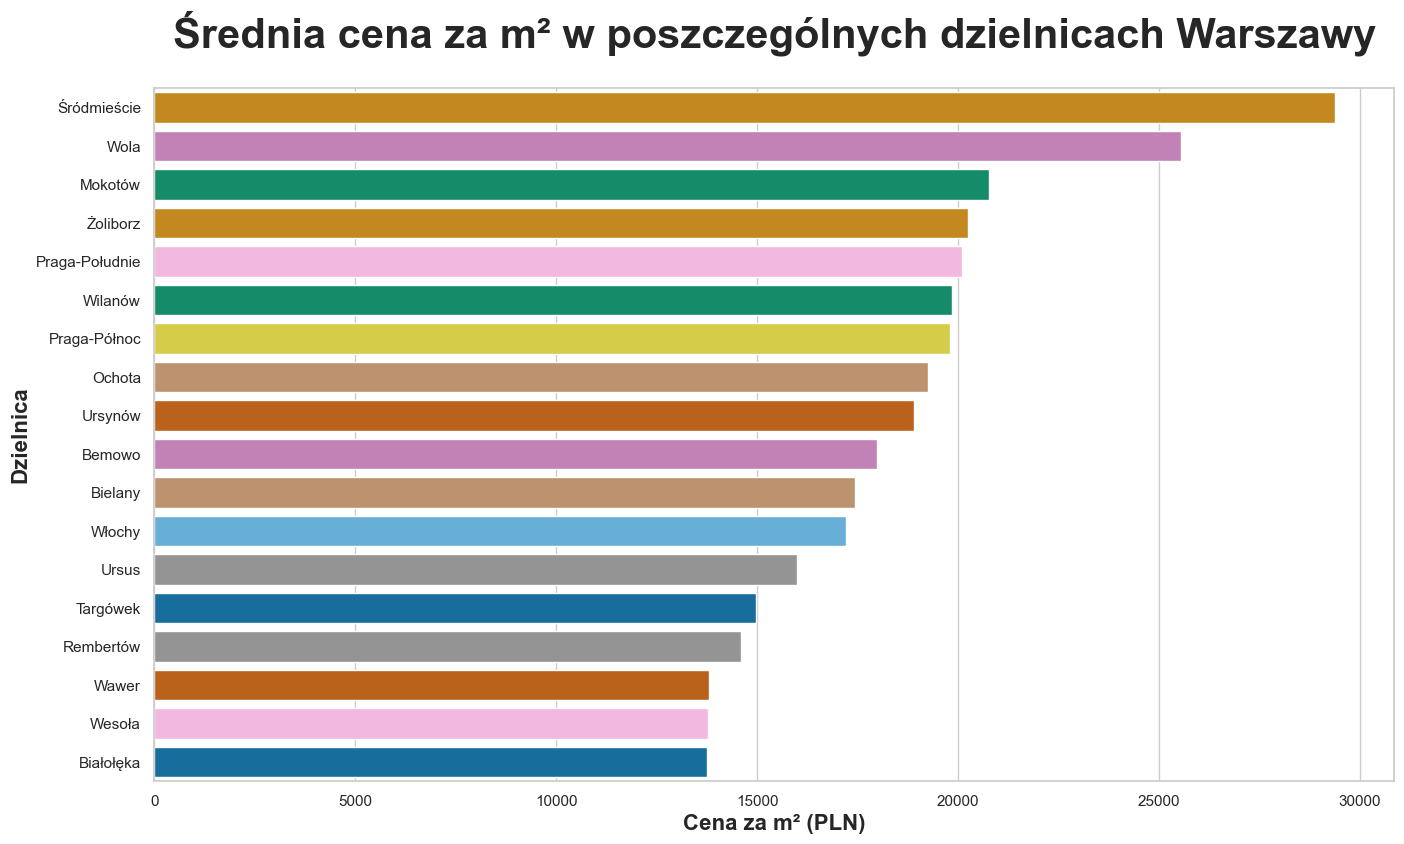

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 9))

sns.barplot(
    data=df_czyste, 
    x='cena_metr_czysta', 
    y='dzielnica', 
    order=kolejnosc, 
    hue='dzielnica',
    palette='colorblind',
    errorbar=None
)

plt.title('Średnia cena za m² w poszczególnych dzielnicach Warszawy', fontsize=30, fontweight='bold', pad=30)
plt.xlabel('Cena za m² (PLN)', fontsize=16, fontweight='bold')
plt.xticks(np.arange(0, 30001, 5000))
plt.ylabel('Dzielnica', fontsize=16, fontweight='bold')
plt.show()

In [5]:
df_czyste2 = df_czyste.dropna(subset=['cena', 'metraż', 'pokoje']).copy()
df_czyste2.shape

(6372, 14)

In [6]:
df_czyste2['cena_czysta'] = (
    df_czyste2['cena']
    .astype(str)
    .str.replace('zł', '')
    .str.replace(' ', '')
)


In [7]:
df_czyste2['metraż_czysta'] = (
    df_czyste2['metraż']
    .astype(str)
    .str.replace('m²', '')
    .str.replace(' ', '')
)

In [8]:
df_czyste2['pokoje_czysta'] = (
    df_czyste2['pokoje']
    .astype(str)
    .str.replace('pokoi', '')
    .str.replace('pokoje', '')
    .str.replace('pokój', '')
    .str.replace('więcej niż', '')
)

In [9]:
df_czyste2['cena_czysta'] = pd.to_numeric(df_czyste2['cena_czysta'], errors='coerce')
df_czyste2['metraż_czysta'] = pd.to_numeric(df_czyste2['metraż_czysta'], errors='coerce')
df_czyste2['pokoje_czysta'] = pd.to_numeric(df_czyste2['pokoje_czysta'], errors='coerce')


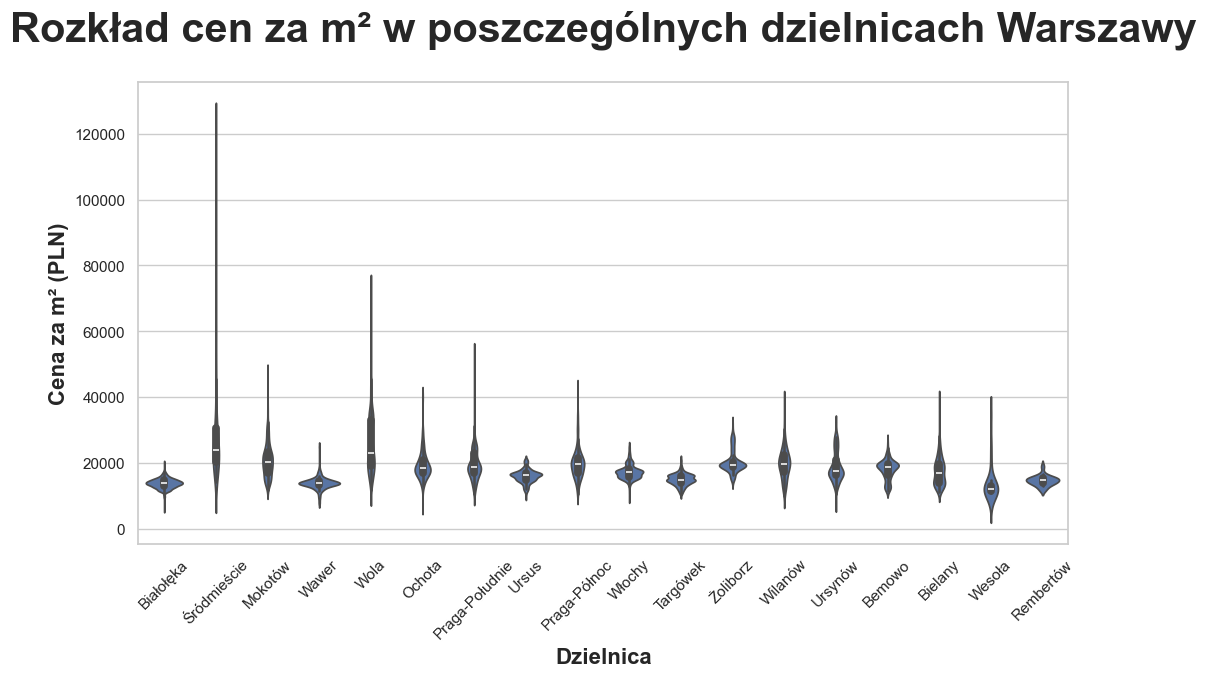

In [10]:
plt.figure(figsize=(12,6))

sns.violinplot(data=df_czyste2,
                x = 'dzielnica',
                y='cena_metr_czysta'
              )
plt.xticks(rotation=45)
plt.xlabel('Dzielnica', fontsize=16, fontweight='bold')
plt.ylabel('Cena za m² (PLN)', fontsize=16, fontweight='bold')
plt.title("Rozkład cen za m² w poszczególnych dzielnicach Warszawy", fontsize=30, fontweight='bold', pad=30)
plt.show()


# Wykresy interaktywne 

In [11]:
dzielnice_mapa = geopandas.read_file('warszawa-dzielnice-poprawione.geojson')

In [12]:
df_zagregowane = df_czyste2.groupby('dzielnica').agg(
    liczba_ofert=('cena_metr_czysta', 'count'),
    średnia_cena_za_metr=('cena_metr_czysta', 'mean'),
    średni_metraż=('metraż_czysta', 'mean'),
    średnia_cena=('cena_czysta', 'mean')
).reset_index()

In [13]:
df_zagregowane['średnia_cena_za_metr'] = df_zagregowane['średnia_cena_za_metr'].round(0)
df_zagregowane['średni_metraż'] = df_zagregowane['średni_metraż'].round(1)
df_zagregowane['średnia_cena'] = df_zagregowane['średnia_cena'].round(0)

In [14]:
mapa_warszawa = dzielnice_mapa.merge(
    df_zagregowane,
    left_on='name',
    right_on='dzielnica'
)

In [15]:
mapa_warszawa['longitude'] = mapa_warszawa['geometry'].centroid.x
mapa_warszawa['latitude'] = mapa_warszawa['geometry'].centroid.y
mapa_warszawa['liczba_ofert'] = mapa_warszawa['liczba_ofert'].astype(str).str.replace(' ', '').str.replace(',', '.')
mapa_warszawa['liczba_ofert'] = pd.to_numeric(mapa_warszawa['liczba_ofert'], errors='coerce')

C:\Users\rutko\AppData\Local\Temp\ipykernel_11088\1506141275.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_warszawa['longitude'] = mapa_warszawa['geometry'].centroid.x
C:\Users\rutko\AppData\Local\Temp\ipykernel_11088\1506141275.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_warszawa['latitude'] = mapa_warszawa['geometry'].centroid.y


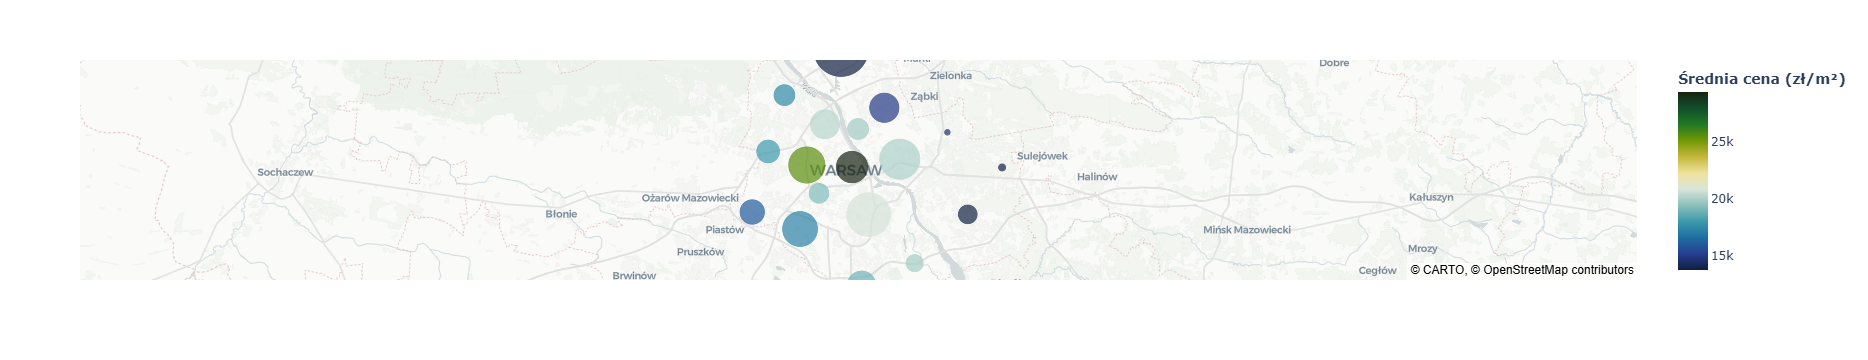

In [16]:
fig = px.scatter_map(
    mapa_warszawa,
    lat='latitude',   
    lon='longitude',
    hover_name='name',
    color_continuous_scale='delta',
    
    hover_data={
        'latitude': False, 
        'longitude': False, 
        'liczba_ofert': True,
        'średnia_cena_za_metr': True,
        'średni_metraż': True,
        'średnia_cena': True,
    },

    labels={
        'średnia_cena_za_metr': '<b>Średnia cena (zł/m²)</b>'
    },
    
    size='liczba_ofert',
    size_max=40,
    color='średnia_cena_za_metr',
    zoom=9,
    map_style="carto-positron",
)


fig.show()

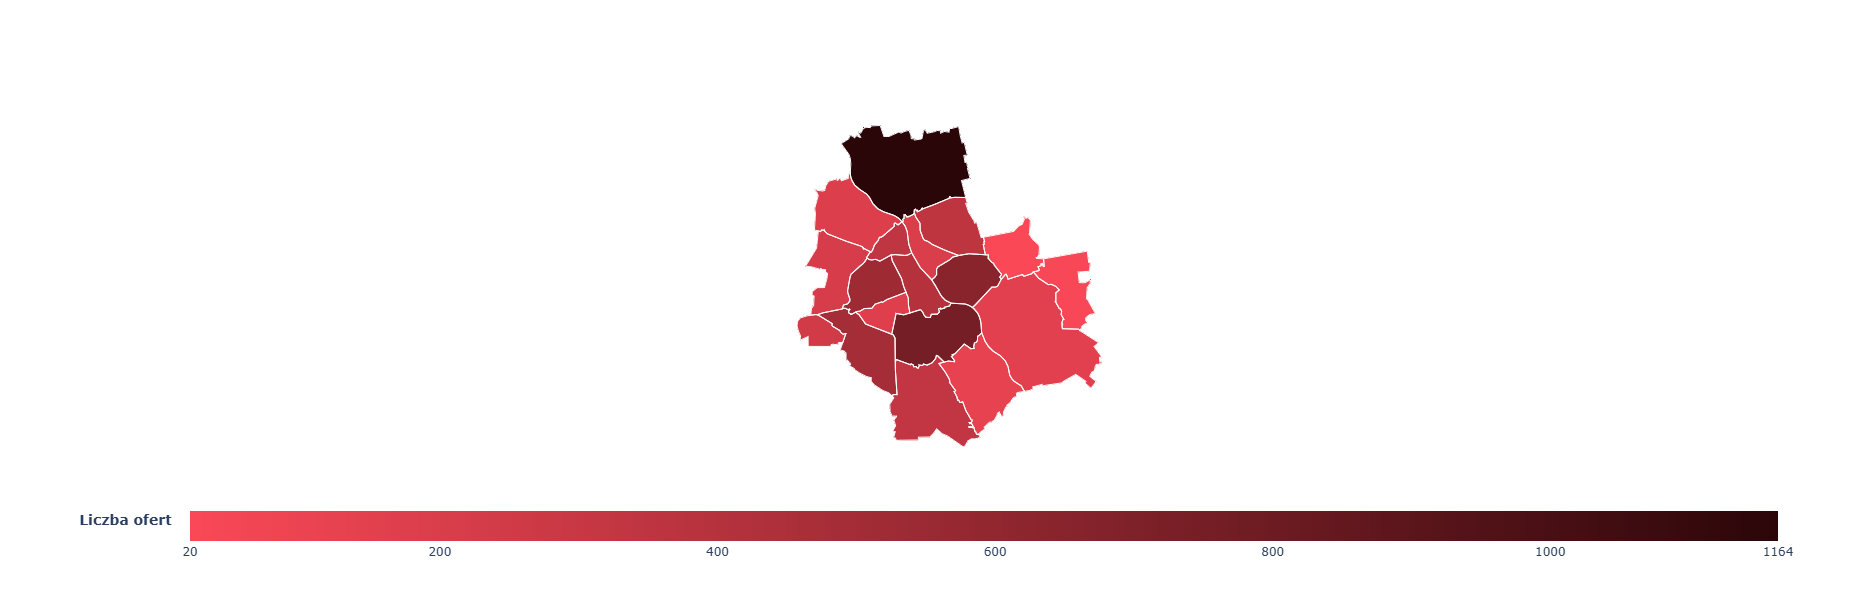

In [17]:
fig = px.choropleth_map(
    mapa_warszawa,
    geojson=mapa_warszawa.geometry,     
    locations=mapa_warszawa.index,
    color='liczba_ofert',               
    hover_name='dzielnica',

    hover_data={
        'liczba_ofert': True, 
        'średnia_cena_za_metr': True
    },

    labels={
        'liczba_ofert': 'Liczba ofert',
        'średnia_cena_za_metr': 'Średnia cena (zł/m²)'
    },

    color_continuous_scale=['#fa4857', '#2b0609'], 
    center={'lat': 52.23, 'lon': 21.04},
    map_style='white-bg',  
    zoom=9,
    height=600,
    width=700,                            
)

fig.update_layout(
    coloraxis_colorbar=dict(
        orientation='h',
        y=-0.1,
    )
)

fig.update_traces(marker_line_width=1, marker_line_color='white')

min_liczba_ofert = mapa_warszawa['liczba_ofert'].min()
max_liczba_ofert = mapa_warszawa['liczba_ofert'].max()

fig.update_layout(
    coloraxis_colorbar=dict(
        title='<b>Liczba ofert</b>',
        tickmode='array',
        tickvals=[min_liczba_ofert, 200, 400, 600, 800, 1000, max_liczba_ofert],
    )
)
#fig.write_html("wykres1.html")
fig.show()

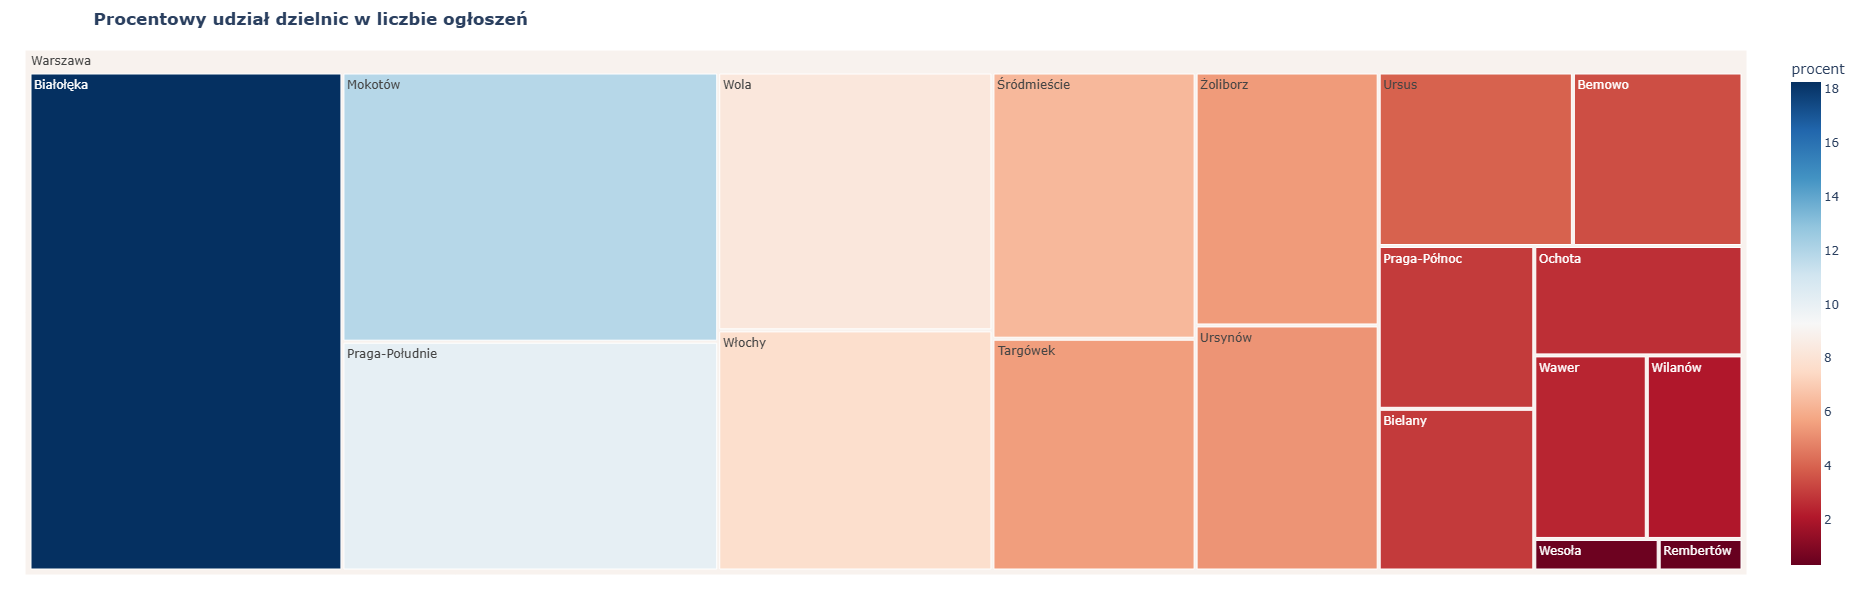

In [18]:
#Treemap Charts
dane_wykres = df_czyste2['dzielnica'].value_counts().reset_index()
dane_wykres.columns = ['dzielnica', 'liczba_ofert']
suma_ofert = dane_wykres['liczba_ofert'].sum()
dane_wykres['procent'] = (dane_wykres['liczba_ofert']/suma_ofert*100).round(2)
dane_wykres['miasto'] = 'Warszawa'


fig = px.treemap(dane_wykres, 
                 path=['miasto', 'dzielnica'], 
                 values='procent',
                 title = '<b>Procentowy udział dzielnic w liczbie ogłoszeń</b>',
                  color='procent', hover_data=['liczba_ofert'],
                  color_continuous_scale='RdBu')
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25),
                 width = 600,
                 height = 600)
fig.show()

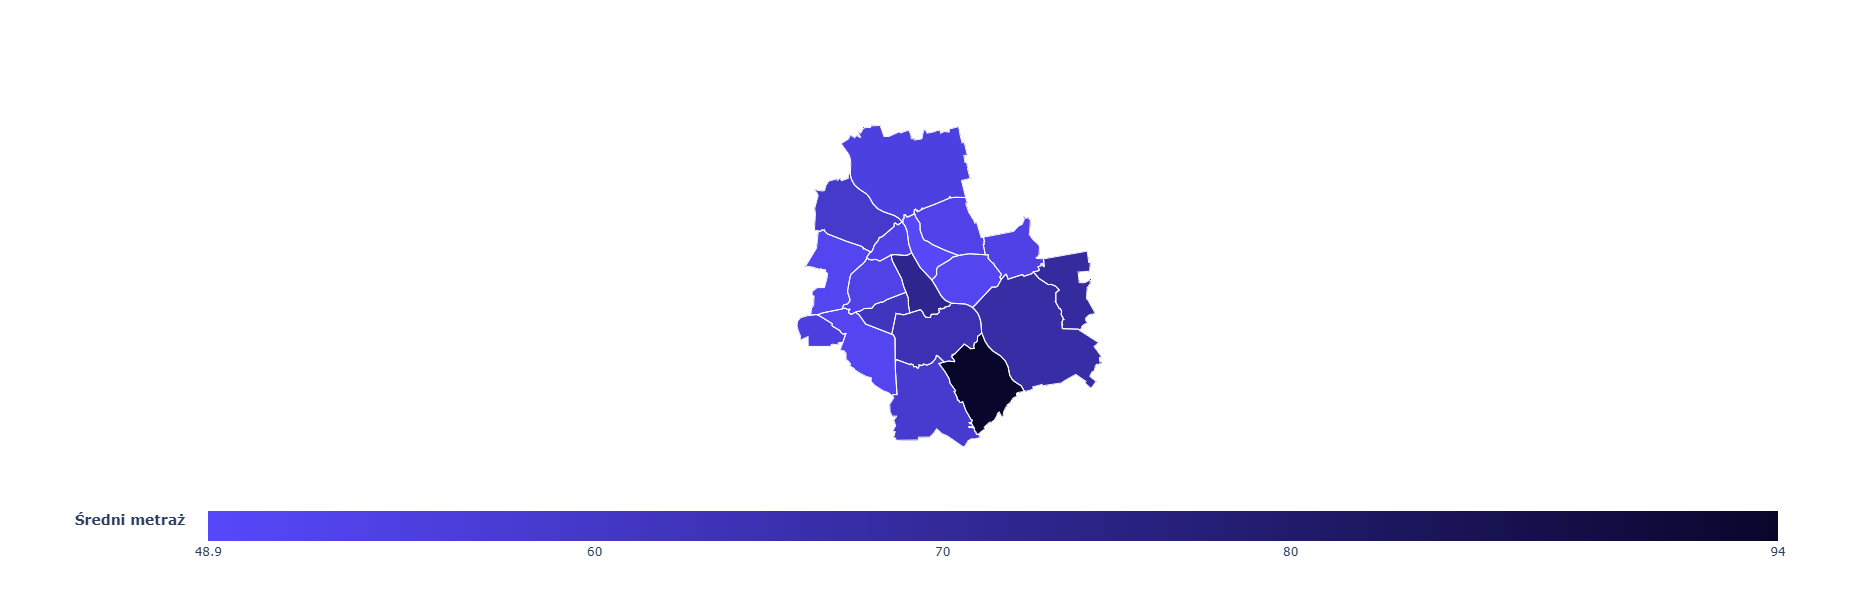

In [19]:
fig = px.choropleth_map(
    mapa_warszawa,
    geojson=mapa_warszawa.geometry,     
    locations=mapa_warszawa.index,
    color='średni_metraż',               
    hover_name='dzielnica',

    hover_data={
        'liczba_ofert': True, 
        'średnia_cena_za_metr': True
    },

    labels={
        'liczba_ofert': 'Liczba ofert',
        'średnia_cena_za_metr': 'Średnia cena (zł/m²)',
        'średni_metraż': 'Średni metraż'
    },

    color_continuous_scale=['#5748fa', '#09062b'], 
    center={'lat': 52.23, 'lon': 21.04},
    map_style='white-bg',  
    zoom=9,
    height=600,
    width=700,                            
)

fig.update_layout(
    coloraxis_colorbar=dict(
        orientation='h',
        y=-0.1,
    )
)
fig.update_traces(marker_line_width=1, marker_line_color='white')

min_metraz = mapa_warszawa['średni_metraż'].min()
max_metraz = mapa_warszawa['średni_metraż'].max()

fig.update_layout(
    coloraxis_colorbar=dict(
        title='<b>Średni metraż</b>',
        tickmode='array',
        tickvals=[min_metraz, 60, 70, 80, max_metraz],
    )
)
#fig.write_html("wykres3.html")
fig.show()